**Mount drive + load processed data**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import numpy as np

PROJECT_ROOT = "/content/drive/MyDrive/bigdata-gbl-quiz"
PROCESSED_FILE = os.path.join(PROJECT_ROOT, "data", "processed", "quiz_features.csv")

df = pd.read_csv(PROCESSED_FILE)
print(df.shape)
df.head()

(19991, 15)


,learner_id,question_id,topic,difficulty,time_spent_seconds,attempts_count,hints_used,correct,time_per_attempt,attempt_index,recent_success_5,recent_hints_5,recent_time_5,questions_completed,avg_difficulty_so_far
0,L0001,Q0103,Geography,2,73,3,2,0,24.333333,1,0.500000,0.0,56.000000,1,2.000000
1,L0001,Q0561,History,2,74,3,1,0,24.666667,2,0.000000,2.0,73.000000,2,2.000000
2,L0001,Q0189,ArtsCulture,1,37,2,0,1,18.500000,3,0.000000,1.5,73.500000,3,2.000000
3,L0001,Q0443,ArtsCulture,1,60,2,1,0,30.000000,4,0.333333,1.0,61.333333,4,1.666667
4,L0001,Q0392,Technology,1,33,2,0,1,16.500000,5,0.250000,1.0,61.000000,5,1.500000


**Create learner-level profile features**

In [3]:
learner_profiles = df.groupby("learner_id").agg(
    accuracy=("correct", "mean"),
    avg_time=("time_spent_seconds", "mean"),
    avg_attempts=("attempts_count", "mean"),
    avg_hints=("hints_used", "mean"),
    avg_difficulty=("difficulty", "mean"),
    total_questions=("correct", "size")
).reset_index()

learner_profiles.head()

,learner_id,accuracy,avg_time,avg_attempts,avg_hints,avg_difficulty,total_questions
0,L0001,0.350000,51.500000,2.200000,0.533333,1.683333,60
1,L0002,0.152941,72.388235,3.458824,0.470588,1.835294,85
2,L0003,0.474576,50.186441,2.118644,0.508475,1.644068,59
3,L0004,0.366197,54.225352,2.338028,0.492958,1.830986,71
4,L0005,0.103896,71.064935,3.324675,0.441558,1.857143,77


**Scale features (needed for clustering)**

In [4]:
from sklearn.preprocessing import StandardScaler

features_for_cluster = ["accuracy", "avg_time", "avg_attempts", "avg_hints", "avg_difficulty", "total_questions"]
X = learner_profiles[features_for_cluster].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(300, 6)

**Choose K (number of clusters) using elbow method**

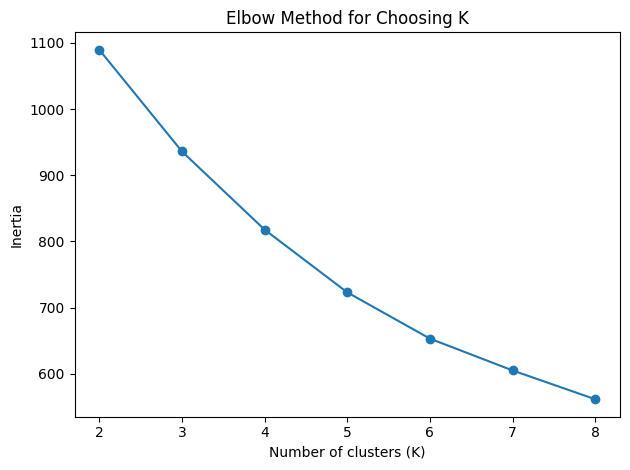

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method for Choosing K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

**Fit KMeans with a chosen K (start with 4)**

In [6]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
learner_profiles["cluster"] = kmeans.fit_predict(X_scaled)

learner_profiles["cluster"].value_counts()

,count
cluster,
3,83
0,74
1,73
2,70


**Interpret the clusters (this is what you write in the report)**

In [7]:
cluster_summary = learner_profiles.groupby("cluster")[features_for_cluster].mean().round(3)
cluster_summary

,accuracy,avg_time,avg_attempts,avg_hints,avg_difficulty,total_questions
cluster,,,,,,
0,0.240,63.613,3.156,0.437,1.650,64.851
1,0.416,54.297,2.303,0.491,1.800,67.466
2,0.469,49.975,2.139,0.541,1.647,64.186
3,0.211,69.195,3.287,0.571,1.787,69.566


**Scatter plot (time vs accuracy) coloured by cluster**

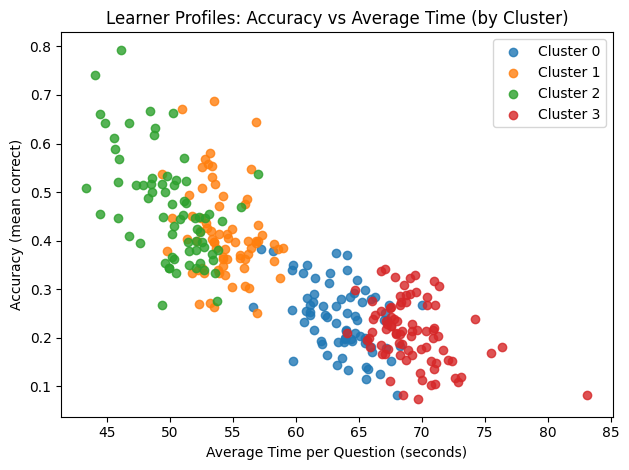

In [8]:
import matplotlib.pyplot as plt

plt.figure()
for c in sorted(learner_profiles["cluster"].unique()):
    temp = learner_profiles[learner_profiles["cluster"] == c]
    plt.scatter(temp["avg_time"], temp["accuracy"], label=f"Cluster {c}", alpha=0.8)

plt.title("Learner Profiles: Accuracy vs Average Time (by Cluster)")
plt.xlabel("Average Time per Question (seconds)")
plt.ylabel("Accuracy (mean correct)")
plt.legend()
plt.tight_layout()
plt.show()

**Bar chart of mean accuracy per cluster**

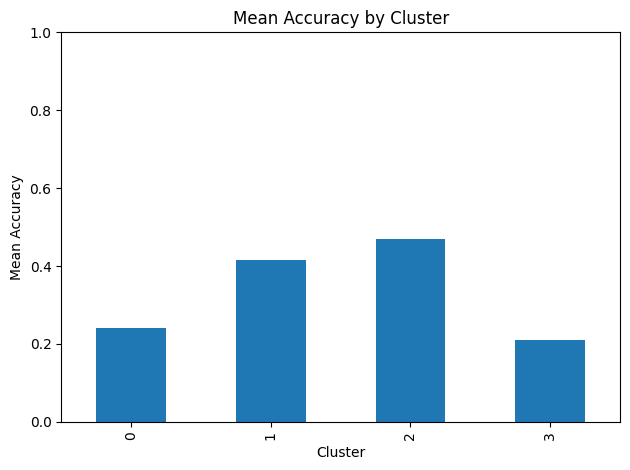

In [9]:
cluster_acc = learner_profiles.groupby("cluster")["accuracy"].mean().sort_index()

plt.figure()
cluster_acc.plot(kind="bar")
plt.title("Mean Accuracy by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Mean Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**Save clustering outputs (step-by-step)**

Set paths (figures + report folders)

In [10]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/bigdata-gbl-quiz"
FIG_DIR = os.path.join(PROJECT_ROOT, "figures")
REPORT_DIR = os.path.join(PROJECT_ROOT, "report")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print("FIG_DIR:", FIG_DIR)
print("REPORT_DIR:", REPORT_DIR)

FIG_DIR: /content/drive/MyDrive/bigdata-gbl-quiz/figures
REPORT_DIR: /content/drive/MyDrive/bigdata-gbl-quiz/report


**Save the cluster summary table as CSV**

In [11]:
cluster_summary_file = os.path.join(REPORT_DIR, "cluster_summary.csv")
cluster_summary.to_csv(cluster_summary_file)

print("✅ Saved:", cluster_summary_file)

✅ Saved: /content/drive/MyDrive/bigdata-gbl-quiz/report/cluster_summary.csv


**Save Plot 1: Accuracy vs Avg Time (by cluster)**

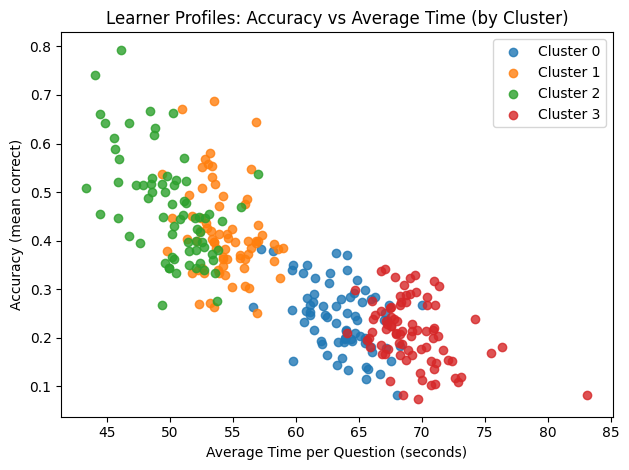

✅ Saved: /content/drive/MyDrive/bigdata-gbl-quiz/figures/cluster_accuracy_vs_time.png


In [12]:
import matplotlib.pyplot as plt

plt.figure()
for c in sorted(learner_profiles["cluster"].unique()):
    temp = learner_profiles[learner_profiles["cluster"] == c]
    plt.scatter(temp["avg_time"], temp["accuracy"], label=f"Cluster {c}", alpha=0.8)

plt.title("Learner Profiles: Accuracy vs Average Time (by Cluster)")
plt.xlabel("Average Time per Question (seconds)")
plt.ylabel("Accuracy (mean correct)")
plt.legend()
plt.tight_layout()

out1 = os.path.join(FIG_DIR, "cluster_accuracy_vs_time.png")
plt.savefig(out1, dpi=200)
plt.show()

print("✅ Saved:", out1)

**Save Plot 2: Mean Accuracy by Cluster**

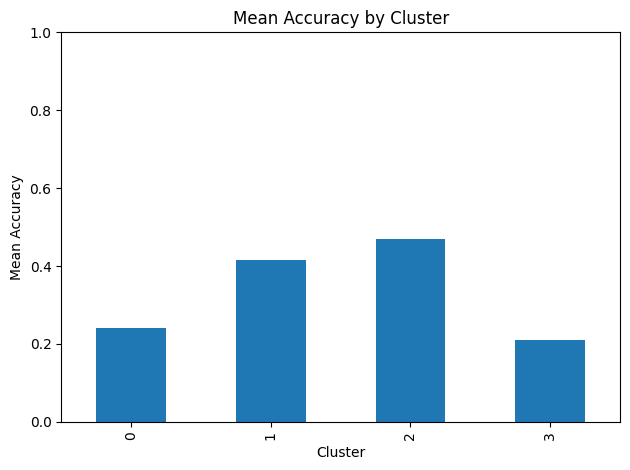

✅ Saved: /content/drive/MyDrive/bigdata-gbl-quiz/figures/cluster_mean_accuracy.png


In [13]:
cluster_acc = learner_profiles.groupby("cluster")["accuracy"].mean().sort_index()

plt.figure()
cluster_acc.plot(kind="bar")
plt.title("Mean Accuracy by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Mean Accuracy")
plt.ylim(0, 1)
plt.tight_layout()

out2 = os.path.join(FIG_DIR, "cluster_mean_accuracy.png")
plt.savefig(out2, dpi=200)
plt.show()

print("✅ Saved:", out2)

**Confirm the files exist (proof)**

In [14]:
print("Exists cluster_summary.csv?", os.path.exists(cluster_summary_file))
print("Exists plot 1?", os.path.exists(out1))
print("Exists plot 2?", os.path.exists(out2))

Exists cluster_summary.csv? True
Exists plot 1? True
Exists plot 2? True
